# Week 41, Monday lecture: backpropagation in general, and a neural network of our own

**FYS-STK3155/4155, Monday October 5, 2026**

This notebook contains the code behind every figure and number in the Monday
slides (`week41monday.pdf`). It follows the lecture: a reminder of the three
small networks of week 40 and of the training program of the lecture notes
(the *template*), the general backpropagation equations of Sections 8.8.3–8.8.5
of the lecture notes, the cost functions for regression (squared error with
$\ell_2$ and/or $\ell_1$ penalties), binary classification (sigmoid and cross
entropy) and $K$ classes (softmax and multiclass cross entropy), and finally a
neural-network code built from the template — checked against finite
differences and `jax.grad`, and run on the Runge function of Project 1, on a
binary classification problem and on the full MNIST set of 70 000 handwritten
digits. 

The weekly exercises (`exercisesweek41.ipynb`, deadline **Friday October 9**)
build the feed-forward part of exactly this kind of network, step by step; the
Tuesday session does the same steps on the digits data.

In [20]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"
GREEN = "#228833"
np.set_printoptions(precision=4, suppress=True)

## Part 1: the reminder — three small networks, one rule (Sections 8.8.1–8.8.2)

Last week we differentiated the three smallest networks by hand. With one node
per layer, $z^1 = w^1 x + b^1$, $a^1 = \sigma(z^1)$ and the half-squared error
$C = \frac12 (a^1 - y)^2$, the *error* of the output node is
$\delta^1 = \partial C/\partial z^1 = (a^1 - y)\,\sigma'(z^1)$, Eq. (8.35), and
$\partial C/\partial w^1 = \delta^1 x$, $\partial C/\partial b^1 = \delta^1$,
Eq. (8.36). With one hidden neuron in front, the output layer obeys the same
formula with $a^1$ in place of $x$, and the hidden error follows from the one
above, Eq. (8.43):

$$
\delta^1 = \delta^2\, w^2\, \sigma'(z^1),
$$

the reverse sweep of automatic differentiation that does not stop at the
output. With two inputs and two hidden nodes the same expressions acquire
indices, Eqs. (8.52)–(8.55): $\delta_j^1 = \delta^2 w_j^2 \sigma'(z_j^1)$,
$\partial C/\partial w_{ij}^l = \delta_j^l a_i^{l-1}$ and
$\partial C/\partial b_j^l = \delta_j^l$ — *the gradient of a weight is the
error at the node it arrives at times the signal at the node it leaves*.

The only thing missing was a node that feeds *several* nodes: then the
contributions of all its successors must be added, and $\delta_j^1$ acquires
the sum $\sum_k \delta_k^2 w_{jk}^2$. That sum is the whole of Part 2.

### The template: the training program of the lecture notes

The program below is the one of (Section 8.8.1): one input,
one hidden sigmoid node, one linear output, $x = 4$, $y = 2x + 1 = 9$, seed 0,
$\gamma = 0.1$. Note the four decisions it already takes: samples are rows and
`x @ w_1 + b_1` is Eq. (8.21); the forward pass stores `a_1`; the hidden error
is the output error pulled back through `w_2.T` and modulated by $\sigma'$;
the weight gradients are outer products summed over the samples, and the bias
gradients column sums. Every one of these survives into the general code.

In [21]:
def sigmoid_template(z):
    return 1.0/(1.0 + np.exp(-z))

def forwardpropagation(x):
    z_1 = np.matmul(x, w_1) + b_1      # hidden pre-activation
    a_1 = sigmoid_template(z_1)        # hidden activation
    z_2 = np.matmul(a_1, w_2) + b_2    # output pre-activation
    a_2 = z_2                          # linear output
    return a_1, a_2

def backpropagation_template(x, y):
    a_1, a_2 = forwardpropagation(x)
    delta_2 = a_2 - y                                      # output error, f' = 1
    delta_1 = np.matmul(delta_2, w_2.T) * a_1 * (1 - a_1)  # hidden error, Eq. (8.43)
    output_weights_gradient = np.matmul(a_1.T, delta_2)
    output_bias_gradient = np.sum(delta_2, axis=0)
    hidden_weights_gradient = np.matmul(x.T, delta_1)
    hidden_bias_gradient = np.sum(delta_1, axis=0)
    return output_weights_gradient, output_bias_gradient, hidden_weights_gradient, hidden_bias_gradient

np.random.seed(0)
x = np.array([[4.0]])
y = 2*x + 1.0
w_1 = np.random.randn(1, 1); b_1 = np.zeros(1) + 0.01
w_2 = np.random.randn(1, 1); b_2 = np.zeros(1) + 0.01
gamma = 0.1
for i in range(50):
    derivW2, derivB2, derivW1, derivB1 = backpropagation_template(x, y)
    if i in (0, 10, 20, 49):
        print(f"iteration {i:2d}: cost = {0.5*np.sum((forwardpropagation(x)[1] - y)**2):.6f}")
    w_2 -= gamma*derivW2;  b_2 -= gamma*derivB2
    w_1 -= gamma*derivW1;  b_1 -= gamma*derivB1
print(f"w_1 = {w_1.ravel()}  b_1 = {b_1}  w_2 = {w_2.ravel()}  b_2 = {b_2}")

iteration  0: cost = 36.895631
iteration 10: cost = 0.426990
iteration 20: cost = 0.004939
iteration 49: cost = 0.000000
w_1 = [1.7958]  b_1 = [0.0179]  w_2 = [4.695]  b_2 = [4.3084]


**Pause and think 1: where is the sum over $k$ in the template?** The fan-out
rule says $\delta_j^1 = \bigl(\sum_k \delta_k^2 w_{jk}^2\bigr)\sigma'(z_j^1)$,
but the template has no loop and no sum. *Answer:* it is in the matrix
product. `delta_2` has shape $(n, M_2)$ and `w_2` shape $(M_1, M_2)$, so
`delta_2 @ w_2.T` has shape $(n, M_1)$ with entry
$(i,j) = \sum_k \delta^2_{ik} w^2_{jk}$ — the sum over the receiving nodes, for
every sample at once. The template was written for $M_2 = 1$, but the line is
already Eq. (8.66) in full. `x.T @ delta_1` sums over the *samples* instead:
entry $(i, j) = \sum_s x_{si}\delta^1_{sj}$, the outer products of Eq. (8.55)
added up. Two sums, two matrix products.

## Part 2: the general case (Sections 8.8.3–8.8.5)

With $z_j^l = \sum_i w_{ij}^l a_i^{l-1} + b_j^l$ and $a_j^l = f(z_j^l)$,
Eq. (8.18) — or $\boldsymbol{Z}^l = \boldsymbol{A}^{l-1}\boldsymbol{W}^l + \boldsymbol{b}^l$
for $n$ samples in rows, Eq. (8.21) — everything follows from two elementary
derivatives, $\partial z_j^l/\partial w_{ij}^l = a_i^{l-1}$ and
$\partial z_j^l/\partial a_i^{l-1} = w_{ij}^l$, Eq. (8.57), and the chain
rule. The result is the four equations of backpropagation, Eqs. (8.65)–(8.68):

$$
\boldsymbol{\delta}^L = f'(\boldsymbol{z}^L)\circ\frac{\partial C}{\partial \boldsymbol{a}^L},
\qquad
\boldsymbol{\delta}^l = \bigl(\boldsymbol{W}^{l+1}\boldsymbol{\delta}^{l+1}\bigr)\circ f'(\boldsymbol{z}^l),
\qquad
\frac{\partial C}{\partial b_j^l} = \delta_j^l,
\qquad
\frac{\partial C}{\partial w_{ij}^l} = \delta_j^l a_i^{l-1}.
$$

The first starts the recursion at the output, the second carries it backwards
through the transpose of the weights (the sum runs over the *second* index of
$w_{jk}^{l+1}$: the same graph, arrows reversed, book Figure 8.13), and the
last two convert the errors into gradients. Every quantity on the right was
computed in the forward pass. For the natural pairings of output activation
and loss the first equation collapses to
$\boldsymbol{\delta}^L = \boldsymbol{a}^L - \boldsymbol{y}$, Eq. (8.69).

For $n$ samples at once (Pause and think 2) the errors are matrices
$\boldsymbol{\Delta}^l$ of shape $(n, M_l)$:
$\boldsymbol{\Delta}^l = \bigl(\boldsymbol{\Delta}^{l+1}(\boldsymbol{W}^{l+1})^T\bigr)\circ f'(\boldsymbol{Z}^l)$,
$\partial C/\partial\boldsymbol{W}^l = (\boldsymbol{A}^{l-1})^T\boldsymbol{\Delta}^l$ and
$\partial C/\partial\boldsymbol{b}^l$ is the column sum of $\boldsymbol{\Delta}^l$.
Two transposes in two places: one pulls the error back through the next
layer, the other sums over the data.

The whole gradient costs about two forward passes whatever the number of
parameters (Proposition 4.2): backpropagation *is* reverse-mode automatic
differentiation specialised to a layered network. Finite differences,
Eq. (4.102), cost one forward pass per parameter — but they are the check
every hand-written backward pass must pass.

### The code: the template with a list of layers, three output heads and two penalties

Below are the functions of `make_week41_figures.py`. `create_layers` returns a
list of $(W, b)$ pairs with $W$ of shape (inputs, outputs) — Xavier-like
variance $1/M_{l-1}$ for the sigmoid and He variance $2/M_{l-1}$ (Eq. 8.74)
for ReLU, biases $0.01$ as in the template. `feed_forward` is Eq. (8.21) in a
loop and keeps every $\boldsymbol{z}^l$ and $\boldsymbol{a}^l$. `backpropagation` is
Eqs. (8.65)–(8.68) transcribed, with the output error `(a[-1] - Y)/n` of
Eq. (8.69) for all three heads and the $\ell_2$ and $\ell_1$ penalties added
to the weight gradients only. `train` is plain gradient descent, Eq. (8.70),
on minibatches.

In [3]:
def sigmoid(z):
    """The logistic function, Eq. (8.22), evaluated without overflow."""
    e = np.exp(-np.abs(z))
    return np.where(z >= 0, 1.0 / (1.0 + e), e / (1.0 + e))


def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)


def relu(z):
    """Eq. (8.23)."""
    return np.maximum(0.0, z)


def relu_prime(z):
    return (z > 0).astype(float)


def identity(z):
    return z


def identity_prime(z):
    return np.ones_like(z)


def softmax(z):
    """Eq. (8.75) with the shift of Eq. (5.30): rows are samples, columns classes."""
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)


ACTIVATIONS = {"sigmoid": (sigmoid, sigmoid_prime),
               "relu": (relu, relu_prime),
               "identity": (identity, identity_prime)}

# The output activation that goes with each cost function (Section 8.11):
# linear output + half-squared error, sigmoid + cross entropy, softmax +
# multiclass cross entropy.  For all three the output error is a^L - y,
# Eq. (8.69), which is why one function serves all of them.
OUTPUT = {"mse": identity, "binary": sigmoid, "softmax": softmax}

In [4]:
def create_layers(sizes, hidden_activation="sigmoid", rng=None):
    """A list of (W, b) pairs, W of shape (inputs, outputs) as in the template.

    sizes = [784, 100, 10] gives two layers: 784 -> 100 -> 10.  The weights are
    drawn with the variance of Eq. (8.74) (He) for ReLU and 1/inputs otherwise,
    the biases are set to 0.01 as in the template.
    """
    rng = np.random.default_rng(2026) if rng is None else rng
    layers = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        scale = np.sqrt(2.0 / n_in) if hidden_activation == "relu" else np.sqrt(1.0 / n_in)
        W = rng.normal(0.0, scale, (n_in, n_out))
        b = np.zeros(n_out) + 0.01
        layers.append((W, b))
    return layers


def feed_forward(X, layers, hidden_activation="sigmoid", head="mse"):
    """Eq. (8.21) layer by layer, samples in rows.

    Returns the lists z (pre-activations) and a (activations, a[0] = X): every
    one of them is needed on the way back, so the forward pass stores them.
    """
    f, _ = ACTIVATIONS[hidden_activation]
    a, z = [X], []
    for l, (W, b) in enumerate(layers):
        zl = a[-1] @ W + b                       # the template's  x @ w_1 + b_1
        z.append(zl)
        if l == len(layers) - 1:
            a.append(OUTPUT[head](zl))           # the output head
        else:
            a.append(f(zl))
    return z, a


def predict(X, layers, hidden_activation="sigmoid", head="mse"):
    """The output of the network: a vector of predictions, probabilities, or class probabilities."""
    return feed_forward(X, layers, hidden_activation, head)[1][-1]


def cost(X, Y, layers, hidden_activation="sigmoid", head="mse", lmbd2=0.0, lmbd1=0.0):
    """The cost of Eq. (8.31): data term for the chosen head plus L2 and L1 penalties on the weights."""
    out = predict(X, layers, hidden_activation, head)
    n = X.shape[0]
    if head == "mse":                            # Eq. (8.32)
        data = 0.5 * np.sum((out - Y) ** 2) / n
    elif head == "binary":                       # Eq. (5.13), averaged
        p = np.clip(out, 1e-12, 1 - 1e-12)
        data = -np.mean(Y * np.log(p) + (1 - Y) * np.log(1 - p))
    else:                                        # Eq. (5.28), averaged, one-hot Y
        p = np.clip(out, 1e-12, 1.0)
        data = -np.mean(np.sum(Y * np.log(p), axis=1))
    reg = sum(lmbd2 * np.sum(W ** 2) + lmbd1 * np.sum(np.abs(W)) for W, _ in layers)
    return data + reg


def backpropagation(X, Y, layers, hidden_activation="sigmoid", head="mse", lmbd2=0.0, lmbd1=0.0):
    """Eqs. (8.65)-(8.68) for all samples at once; returns a list of (dW, db) with the shapes of (W, b)."""
    _, fp = ACTIVATIONS[hidden_activation]
    n = X.shape[0]
    z, a = feed_forward(X, layers, hidden_activation, head)
    delta = (a[-1] - Y) / n                      # Eq. (8.69): the same line for all three heads
    grads = [None] * len(layers)
    for l in range(len(layers) - 1, -1, -1):
        W, _ = layers[l]
        dW = a[l].T @ delta                      # Eq. (8.68): outer products, summed over the samples
        dW += 2.0 * lmbd2 * W + lmbd1 * np.sign(W)   # the penalties of Section 8.12 (weights only)
        db = np.sum(delta, axis=0)               # Eq. (8.67)
        grads[l] = (dW, db)
        if l > 0:
            delta = (delta @ W.T) * fp(z[l - 1])     # Eq. (8.66): pull back through W, modulate by f'
    return grads


def accuracy(X, y, layers, hidden_activation, head):
    """Fraction of correct labels; y holds integer labels for softmax, 0/1 for binary."""
    out = predict(X, layers, hidden_activation, head)
    if head == "softmax":
        return np.mean(np.argmax(out, axis=1) == y)
    return np.mean((out[:, 0] > 0.5) == (y > 0.5))


def train(X, Y, layers, hidden_activation="sigmoid", head="mse", gamma=0.1, epochs=100,
          batch_size=None, lmbd2=0.0, lmbd1=0.0, rng=None, X_test=None, y_test=None, verbose=False):
    """Plain gradient descent, Eq. (8.70), on minibatches (batch_size=None: the whole set).

    Returns the trained layers and a history with the training cost after
    every epoch and, when a test set is given, the test accuracy.
    """
    rng = np.random.default_rng(2026) if rng is None else rng
    n = X.shape[0]
    M = n if batch_size is None else batch_size
    history = {"cost": [], "test_accuracy": []}
    for epoch in range(epochs):
        order = rng.permutation(n)
        for s in range(0, n, M):
            idx = order[s:s + M]
            grads = backpropagation(X[idx], Y[idx], layers, hidden_activation, head, lmbd2, lmbd1)
            layers = [(W - gamma * dW, b - gamma * db) for (W, b), (dW, db) in zip(layers, grads)]
        history["cost"].append(cost(X, Y, layers, hidden_activation, head, lmbd2, lmbd1))
        if X_test is not None:
            history["test_accuracy"].append(accuracy(X_test, y_test, layers, hidden_activation, head))
        if verbose:
            msg = f"epoch {epoch + 1:3d}: cost {history['cost'][-1]:.4f}"
            if X_test is not None:
                msg += f"  test accuracy {history['test_accuracy'][-1]:.4f}"
            print(msg)
    return layers, history


def one_hot(y, n_classes=None):
    """Integer labels -> one-hot rows."""
    n_classes = int(np.max(y)) + 1 if n_classes is None else n_classes
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y


The template, recovered: two layers of one node, the same seed-0 weights and
$\gamma = 0.1$ give every digit of the program above.

In [5]:
rng0 = np.random.RandomState(0)
layers = [(rng0.randn(1, 1), np.zeros(1) + 0.01), (rng0.randn(1, 1), np.zeros(1) + 0.01)]
x4, y9 = np.array([[4.0]]), np.array([[9.0]])
for it in range(50):
    if it in (0, 10, 20):
        print(f"iteration {it:2d}: cost = {cost(x4, y9, layers, 'sigmoid', 'mse'):.6f}")
    grads = backpropagation(x4, y9, layers, "sigmoid", "mse")
    layers = [(Wl - 0.1*dW, bl - 0.1*db) for (Wl, bl), (dW, db) in zip(layers, grads)]
print(f"iteration 49: cost = {cost(x4, y9, layers, 'sigmoid', 'mse'):.6f}; "
      f"w_1 = {layers[0][0].ravel()}, w_2 = {layers[1][0].ravel()}")

iteration  0: cost = 36.895631
iteration 10: cost = 0.426990
iteration 20: cost = 0.004939
iteration 49: cost = 0.000000; w_1 = [1.7958], w_2 = [4.695]


### Checking the gradient: finite differences and `jax.grad`

Two independent referees. `gradient_check` perturbs twenty random weights per
layer by $h = 10^{-6}$ and compares the central difference of Eq. (4.102) with
the analytical gradient; the relative discrepancy should be $10^{-6}$ or
smaller. `jax_cost` is the same cost written once more in `jax.numpy` — the
forward pass and nothing else — and `jax.grad` differentiates it by
reverse-mode automatic differentiation; the difference should be machine
precision. A network with two hidden layers of 7 and 6 units, both
activations, both penalties switched on, all three heads.

In [6]:
def gradient_check(X, Y, layers, hidden_activation, head, lmbd2=0.0, lmbd1=0.0, h=1e-6, n_samples=20, rng=None):
    """Largest relative discrepancy between backpropagation and the central difference, Eq. (4.102)."""
    rng = np.random.default_rng(2026) if rng is None else rng
    grads = backpropagation(X, Y, layers, hidden_activation, head, lmbd2, lmbd1)
    worst = 0.0
    for l, (W, b) in enumerate(layers):
        for _ in range(n_samples):
            i, j = rng.integers(W.shape[0]), rng.integers(W.shape[1])
            Wp, Wm = W.copy(), W.copy()
            Wp[i, j] += h
            Wm[i, j] -= h
            cp = cost(X, Y, layers[:l] + [(Wp, b)] + layers[l + 1:], hidden_activation, head, lmbd2, lmbd1)
            cm = cost(X, Y, layers[:l] + [(Wm, b)] + layers[l + 1:], hidden_activation, head, lmbd2, lmbd1)
            num = (cp - cm) / (2 * h)
            ana = grads[l][0][i, j]
            worst = max(worst, abs(num - ana) / (abs(num) + abs(ana) + 1e-12))
    return worst


def jax_cost(params, X, Y, hidden_activation="sigmoid", head="mse", lmbd2=0.0, lmbd1=0.0):
    """The same cost as `cost`, written in jax.numpy so that jax.grad can differentiate it."""
    import jax.numpy as jnp
    import jax
    f = {"sigmoid": jax.nn.sigmoid, "relu": jax.nn.relu, "identity": lambda z: z}[hidden_activation]
    a = X
    for l, (W, b) in enumerate(params):
        z = a @ W + b
        if l < len(params) - 1:
            a = f(z)
        elif head == "mse":
            a = z
        elif head == "binary":
            a = jax.nn.sigmoid(z)
        else:
            a = jax.nn.softmax(z, axis=1)
    n = X.shape[0]
    if head == "mse":
        data = 0.5 * jnp.sum((a - Y) ** 2) / n
    elif head == "binary":
        data = -jnp.mean(Y * jnp.log(a) + (1 - Y) * jnp.log(1 - a))
    else:
        data = -jnp.mean(jnp.sum(Y * jnp.log(a), axis=1))
    reg = sum(lmbd2 * jnp.sum(W ** 2) + lmbd1 * jnp.sum(jnp.abs(W)) for W, _ in params)
    return data + reg


def jax_check(X, Y, layers, hidden_activation, head, lmbd2=0.0, lmbd1=0.0):
    """Largest absolute difference between backpropagation and jax.grad, over all weights and biases."""
    import jax
    import jax.numpy as jnp
    jax.config.update("jax_enable_x64", True)
    g_hand = backpropagation(X, Y, layers, hidden_activation, head, lmbd2, lmbd1)
    params = [(jnp.array(W), jnp.array(b)) for W, b in layers]
    g_jax = jax.grad(jax_cost)(params, jnp.array(X), jnp.array(Y), hidden_activation, head, lmbd2, lmbd1)
    return max(float(jnp.max(jnp.abs(jnp.array(h) - j))) for gh, gj in zip(g_hand, g_jax) for h, j in zip(gh, gj))


In [7]:
rng = np.random.default_rng(2026)
Xc = rng.normal(size=(20, 5))
print(f"{'head':8s} {'hidden':8s} {'sizes':16s} finite differences   jax.grad")
for head, Yc in (("mse", rng.normal(size=(20, 2))),
                 ("binary", rng.integers(0, 2, size=(20, 1)).astype(float)),
                 ("softmax", one_hot(rng.integers(0, 3, size=20), 3))):
    for act in ("sigmoid", "relu"):
        sizes = [5, 7, 6, Yc.shape[1]]
        lay = create_layers(sizes, act, rng)
        fd = gradient_check(Xc, Yc, lay, act, head, lmbd2=1e-3, lmbd1=1e-3)
        jx = jax_check(Xc, Yc, lay, act, head, lmbd2=1e-3, lmbd1=1e-3)
        print(f"{head:8s} {act:8s} {str(sizes):16s} {fd:.2e}             {jx:.2e}")

head     hidden   sizes            finite differences   jax.grad
mse      sigmoid  [5, 7, 6, 2]     8.48e-08             1.11e-16
mse      relu     [5, 7, 6, 2]     5.80e-08             4.44e-16
binary   sigmoid  [5, 7, 6, 1]     6.50e-08             4.16e-17
binary   relu     [5, 7, 6, 1]     1.19e-08             2.78e-17
softmax  sigmoid  [5, 7, 6, 3]     9.28e-07             5.55e-17
softmax  relu     [5, 7, 6, 3]     3.57e-08             5.55e-17


mse      sigmoid  [5, 7, 6, 2]     8.48e-08             1.11e-16
mse      relu     [5, 7, 6, 2]     5.80e-08             4.44e-16


binary   sigmoid  [5, 7, 6, 1]     6.50e-08             4.16e-17
binary   relu     [5, 7, 6, 1]     1.19e-08             5.55e-17


softmax  sigmoid  [5, 7, 6, 3]     9.28e-07             5.55e-17
softmax  relu     [5, 7, 6, 3]     3.57e-08             5.55e-17


## Part 3: cost functions and output layers (Sections 8.7, 8.11–8.12, Chapter 5)

The loss follows the distribution of the target (Section 3.6), the output
activation its range, and for the three natural pairings the output error is
prediction minus target:

| Task | Output activation | Loss of one sample | $\partial L/\partial a^L$ | $\delta^L$ |
|---|---|---|---|---|
| regression, $y\in\mathbb{R}$ | linear, $a^L = z^L$ | $\tfrac12 (a^L - y)^2$, Eq. (8.32) | $a^L - y$ | $a^L - y$ |
| binary, $y\in\{0,1\}$ | sigmoid, $a^L = \sigma(z^L)$ | $-y\ln a^L - (1-y)\ln(1-a^L)$, Eq. (5.13) | $(a^L - y)/\bigl(a^L(1-a^L)\bigr)$ | $a^L - y$ |
| $K$ classes, one-hot $\boldsymbol{y}$ | softmax, $a_k^L = e^{z_k^L}/\sum_l e^{z_l^L}$, Eq. (8.75) | $-\sum_k y_k \ln a_k^L$, Eq. (5.28) | $-y_k/a_k^L$ | $\boldsymbol{a}^L - \boldsymbol{y}$ |

**Regression.** With the $\ell_2$ and $\ell_1$ penalties of Section 8.12,
$C = \frac{1}{2n}\sum_i (a_i^L - y_i)^2 + \lambda_2\sum |w|^2 + \lambda_1\sum|w|$,
the penalties depend on the weights directly and add
$2\lambda_2 w_{ij}^l + \lambda_1\,\mathrm{sign}(w_{ij}^l)$ to the weight
gradients only (biases are not penalised). $\ell_2$ *decays* every weight by
a factor before the gradient step; $\ell_1$ pulls with a constant force, so
small weights reach exactly zero and stay there.

**Binary classification.** $\partial L/\partial a^L = (a^L - y)/(a^L(1-a^L))$
and $\sigma'(z^L) = a^L(1-a^L)$ cancel: $\delta^L = a^L - y$, Eq. (5.36) of
week 39 at the output of a network. Logistic regression is the network with
$L = 1$, and a classification network is logistic regression on the learned
features $\boldsymbol{a}^{L-1}$.

**$K$ classes.** The softmax Jacobian is
$\partial a_k/\partial z_j = a_k(\delta_{kj} - a_j)$ — not diagonal — and with
the multiclass cross entropy
$\delta_j^L = \sum_k (-y_k/a_k)\,a_k(\delta_{kj} - a_j) = -y_j + a_j\sum_k y_k = a_j - y_j$.
The $a_k$ of the Jacobian cancels the $1/a_k$ of the logarithm, and
$\sum_k y_k = 1$ does the rest. Since $\sum_k a_k = 1$ as well, the $K$ output
errors of every sample sum to zero (Pause and think 3): one output node is
redundant, and the gradient has no component along the shift direction that
the softmax ignores.

### Why not the squared error for classification?

One sigmoid output node with target $y = 1$: the cross entropy gives an output
error $|a - y| \to 1$ as $z \to -\infty$, the squared error gives
$|a - y|\,\sigma'(z)$, which vanishes exactly where the network is confidently
wrong.

In [8]:
def fig_delta_heads(fname="week41_delta_heads.pdf"):
    z = np.linspace(-8, 8, 400)
    a = sigmoid(z)
    y = 1.0
    loss_ce = -np.log(a)                              # sigmoid + cross entropy, y = 1
    loss_mse_sig = 0.5 * (a - y) ** 2                 # sigmoid + half-squared error
    delta_ce = a - y                                  # Eq. (8.69)
    delta_mse_sig = (a - y) * a * (1 - a)             # Eq. (8.65) with f' = sigma'
    delta_lin = z - y                                 # linear output + half-squared error
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    ax[0].plot(z, loss_ce, color=BLUE, lw=2, label=r"sigmoid + cross entropy, $-\ln a$")
    ax[0].plot(z, loss_mse_sig, color=RED, lw=2, label=r"sigmoid + squared error, $\frac{1}{2}(a-1)^2$")
    ax[0].set_xlabel(r"pre-activation $z$ (target $y=1$)")
    ax[0].set_ylabel("loss")
    ax[0].set_ylim(-0.1, 4)
    ax[0].legend(fontsize=8, loc="upper right")
    ax[0].set_title("(a) the loss of one output node", fontsize=10)
    ax[1].plot(z, np.abs(delta_ce), color=BLUE, lw=2, label=r"sigmoid + cross entropy: $|a-y|$")
    ax[1].plot(z, np.abs(delta_mse_sig), color=RED, lw=2, label=r"sigmoid + squared error: $|a-y|\,\sigma'(z)$")
    ax[1].plot(z, np.abs(delta_lin) / 8, color=GREY, lw=1.5, ls="--", label=r"linear + squared error: $|z-y|$ (scaled by 1/8)")
    ax[1].set_xlabel(r"pre-activation $z$ (target $y=1$)")
    ax[1].set_ylabel(r"$|\delta^L| = |\partial L/\partial z|$")
    ax[1].set_ylim(-0.05, 1.5)
    ax[1].legend(fontsize=8, loc="upper right")
    ax[1].set_title(r"(b) the output error $\delta^L$ that starts the backward pass", fontsize=10)
    for axis in ax:
        axis.axvline(0, color=GREY, lw=0.5)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)
    zz = -5.0
    aa = sigmoid(zz)
    return {"z": zz, "a": aa, "delta_ce": aa - 1, "delta_mse_sig": (aa - 1) * aa * (1 - aa)}


at z = -5.0: a = 0.00669, cross-entropy delta = -0.99331, squared-error delta = -0.00660, ratio 150


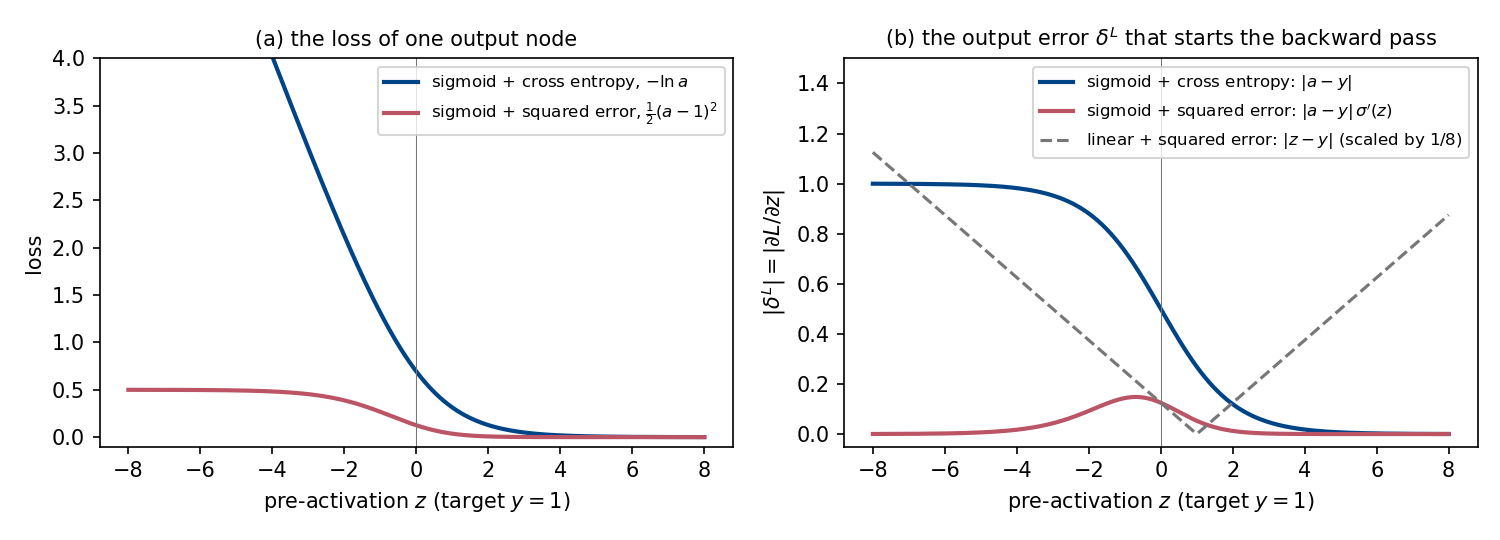

In [9]:
r = fig_delta_heads()
print(f"at z = {r['z']}: a = {r['a']:.5f}, cross-entropy delta = {r['delta_ce']:.5f}, "
      f"squared-error delta = {r['delta_mse_sig']:.5f}, ratio {r['delta_ce']/r['delta_mse_sig']:.0f}")
Image("week41_delta_heads.png", width=900)

## Part 4: the code at work

### Example 1, regression: the Runge function of Project 1

$f(x) = 1/(1 + 25x^2)$ on $[-1, 1]$, $n = 100$ training points with noise
$\sigma = 0.1$ and a separate test set of 100 points (seed 2026); a 1–50–1
network, linear output, half-squared error, plain full-batch gradient descent
for 20 000 steps. First sigmoid against ReLU hidden units at three learning
rates: the sigmoid network is slow and at $\gamma = 0.5$ collapses to
predicting the mean (the hidden layer saturates in the first steps — the
$\gamma = 1$ run of week 40 with fifty neurons); ReLU at $\gamma = 0.1$
reaches the noise floor, MSE $\approx \sigma^2 = 0.01$.

In [10]:
def runge_data(n=100, sigma=0.1, seed=2026):
    """The data of Project 1: x uniform on [-1, 1], y = 1/(1 + 25 x^2) + noise; a train and a test set."""
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1, 1, n))
    y = 1.0 / (1.0 + 25 * x ** 2) + rng.normal(0, sigma, n)
    x_test = np.sort(rng.uniform(-1, 1, n))
    y_test = 1.0 / (1.0 + 25 * x_test ** 2) + rng.normal(0, sigma, n)
    return x[:, None], y[:, None], x_test[:, None], y_test[:, None]


In [11]:
Xr, Yr, Xrt, Yrt = runge_data()
print(f"var(y) = {Yr.var():.4f} (the MSE of predicting the mean); noise variance 0.01")
t0 = time.time()
for act in ("sigmoid", "relu"):
    for gamma in (0.1, 0.2, 0.5):
        lay = create_layers([1, 50, 1], act, np.random.default_rng(2026))
        lay, h = train(Xr, Yr, lay, act, "mse", gamma=gamma, epochs=20000)
        print(f"{act:8s} gamma {gamma}: train MSE {np.mean((predict(Xr, lay, act, 'mse') - Yr)**2):.4f}  "
              f"test MSE {np.mean((predict(Xrt, lay, act, 'mse') - Yrt)**2):.4f}  "
              f"cost after 100 steps {h['cost'][100]:.4f}")
print(f"({time.time() - t0:.0f} s)")

var(y) = 0.1025 (the MSE of predicting the mean); noise variance 0.01
sigmoid  gamma 0.1: train MSE 0.0237  test MSE 0.0184  cost after 100 steps 0.0511
sigmoid  gamma 0.2: train MSE 0.0169  test MSE 0.0124  cost after 100 steps 0.0461
sigmoid  gamma 0.5: train MSE 0.1024  test MSE 0.1057  cost after 100 steps 0.0550
relu     gamma 0.1: train MSE 0.0128  test MSE 0.0094  cost after 100 steps 0.0128
relu     gamma 0.2: train MSE 0.0129  test MSE 0.0095  cost after 100 steps 0.0146
relu     gamma 0.5: train MSE 0.0815  test MSE 0.0868  cost after 100 steps 0.0429
(15 s)


sigmoid  gamma 0.1: train MSE 0.0237  test MSE 0.0184  cost after 100 steps 0.0511


sigmoid  gamma 0.2: train MSE 0.0169  test MSE 0.0124  cost after 100 steps 0.0461


sigmoid  gamma 0.5: train MSE 0.1024  test MSE 0.1057  cost after 100 steps 0.0550


relu     gamma 0.1: train MSE 0.0128  test MSE 0.0094  cost after 100 steps 0.0128


relu     gamma 0.2: train MSE 0.0129  test MSE 0.0095  cost after 100 steps 0.0146


relu     gamma 0.5: train MSE 0.0815  test MSE 0.0868  cost after 100 steps 0.0429
(16 s)


Now the penalties, ReLU hidden units, $\gamma = 0.1$: $\lambda$ from $10^{-5}$
to $10^{-1}$ for $\ell_2$ and for $\ell_1$. With $n = 100$ and 20 000 steps the
unpenalised network is not overfitting, so both penalties only *cost* accuracy
here — but panel (c) shows what they do to the weights: $\ell_1$ sends forty of
the fifty hidden weights below $10^{-3}$ and keeps ten, $\ell_2$ shrinks all
fifty by a factor and zeroes none (Pause and think 4: a ReLU node with
$w^1_{1j} = 0$ computes a constant, which folds into the output bias, so the
$\ell_1$ network is effectively a 1–10–1 network — the penalty has selected
the architecture, as the Lasso selected features in Chapter 3).

In [12]:
def fig_runge(fname="week41_runge.pdf", hidden=50, act="relu", gamma=0.1, epochs=20000, lambdas=(1e-5, 1e-4, 1e-3, 1e-2, 1e-1)):
    X, Y, Xt, Yt = runge_data()
    xx = np.linspace(-1, 1, 400)[:, None]
    results = {}

    def run(lmbd2, lmbd1):
        layers = create_layers([1, hidden, 1], act, np.random.default_rng(2026))
        layers, hist = train(X, Y, layers, act, "mse", gamma=gamma, epochs=epochs, lmbd2=lmbd2, lmbd1=lmbd1)
        mse_train = np.mean((predict(X, layers, act, "mse") - Y) ** 2)
        mse_test = np.mean((predict(Xt, layers, act, "mse") - Yt) ** 2)
        return layers, mse_train, mse_test

    layers0, tr0, te0 = run(0.0, 0.0)
    results[("none", 0.0)] = (tr0, te0)
    curves = {"L2": [], "L1": []}
    fits = {}
    for lmbd in lambdas:
        l2, tr, te = run(lmbd, 0.0)
        curves["L2"].append((tr, te))
        results[("L2", lmbd)] = (tr, te)
        l1, tr1, te1 = run(0.0, lmbd)
        curves["L1"].append((tr1, te1))
        results[("L1", lmbd)] = (tr1, te1)
        if lmbd == 1e-3:
            fits["L2"], fits["L1"] = l2, l1
    W0 = np.abs(layers0[0][0]).ravel()
    W2 = np.abs(fits["L2"][0][0]).ravel()
    W1 = np.abs(fits["L1"][0][0]).ravel()
    results["n_small_weights"] = {k: int(np.sum(w < 1e-3)) for k, w in (("none", W0), ("L2", W2), ("L1", W1))}

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
    ax[0].plot(X, Y, "o", color=GREY, ms=3, label="training data")
    ax[0].plot(xx, 1 / (1 + 25 * xx ** 2), color="k", lw=1, ls=":", label="Runge function")
    ax[0].plot(xx, predict(xx, layers0, act, "mse"), color=BLUE, lw=2, label=rf"$\lambda=0$: test MSE {te0:.4f}")
    ax[0].plot(xx, predict(xx, fits["L2"], act, "mse"), color=RED, lw=2,
               label=rf"L2, $\lambda=10^{{-3}}$: test MSE {results[('L2', 1e-3)][1]:.4f}")
    ax[0].plot(xx, predict(xx, fits["L1"], act, "mse"), color=GREEN, lw=2, ls="--",
               label=rf"L1, $\lambda=10^{{-3}}$: test MSE {results[('L1', 1e-3)][1]:.4f}")
    ax[0].set_xlabel("$x$")
    ax[0].set_ylabel("$y$")
    ax[0].legend(fontsize=7, loc="upper left")
    ax[0].set_title(f"(a) 1-{hidden}-1 network, {epochs} GD steps", fontsize=10)
    lam = np.array(lambdas)
    ax[1].semilogx(lam, [c[1] for c in curves["L2"]], "o-", color=RED, label="L2, test")
    ax[1].semilogx(lam, [c[0] for c in curves["L2"]], "o--", color=RED, mfc="white", label="L2, train")
    ax[1].semilogx(lam, [c[1] for c in curves["L1"]], "s-", color=GREEN, label="L1, test")
    ax[1].semilogx(lam, [c[0] for c in curves["L1"]], "s--", color=GREEN, mfc="white", label="L1, train")
    ax[1].axhline(te0, color=BLUE, lw=1, label=r"$\lambda=0$, test")
    ax[1].axhline(tr0, color=BLUE, lw=1, ls="--", label=r"$\lambda=0$, train")
    ax[1].axhline(0.01, color=GREY, lw=0.8, ls=":", label=r"noise $\sigma^2$")
    ax[1].set_xlabel(r"$\lambda$")
    ax[1].set_ylabel("MSE")
    ax[1].set_yscale("log")
    ax[1].legend(fontsize=7, ncol=2)
    ax[1].set_title("(b) the penalty as a knob", fontsize=10)
    ax[2].semilogy(np.sort(W0)[::-1] + 1e-12, color=BLUE, lw=2, label=r"$\lambda=0$")
    ax[2].semilogy(np.sort(W2)[::-1] + 1e-12, color=RED, lw=2, label=r"L2, $10^{-3}$")
    ax[2].semilogy(np.sort(W1)[::-1] + 1e-12, color=GREEN, lw=2, ls="--", label=r"L1, $10^{-3}$")
    ax[2].set_xlabel("hidden weight, sorted by size")
    ax[2].set_ylabel(r"$|w^{1}_{1j}|$")
    ax[2].set_ylim(1e-6, 1e2)
    ax[2].legend(fontsize=8)
    ax[2].set_title("(c) what the two penalties do to the weights", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)
    return results


none  lambda = 0        train MSE 0.0128  test MSE 0.0094
L2    lambda = 1e-05    train MSE 0.0128  test MSE 0.0094
L1    lambda = 1e-05    train MSE 0.0128  test MSE 0.0094
L2    lambda = 0.0001   train MSE 0.0134  test MSE 0.0095
L1    lambda = 0.0001   train MSE 0.0132  test MSE 0.0095
L2    lambda = 0.001    train MSE 0.0228  test MSE 0.0171
L1    lambda = 0.001    train MSE 0.0168  test MSE 0.0118
L2    lambda = 0.01     train MSE 0.0507  test MSE 0.0452
L1    lambda = 0.01     train MSE 0.0393  test MSE 0.0329
L2    lambda = 0.1      train MSE 0.1025  test MSE 0.1057
L1    lambda = 0.1      train MSE 0.1025  test MSE 0.1057
hidden weights below 1e-3 (of 50): {'none': 0, 'L2': 0, 'L1': 40}
(19 s)


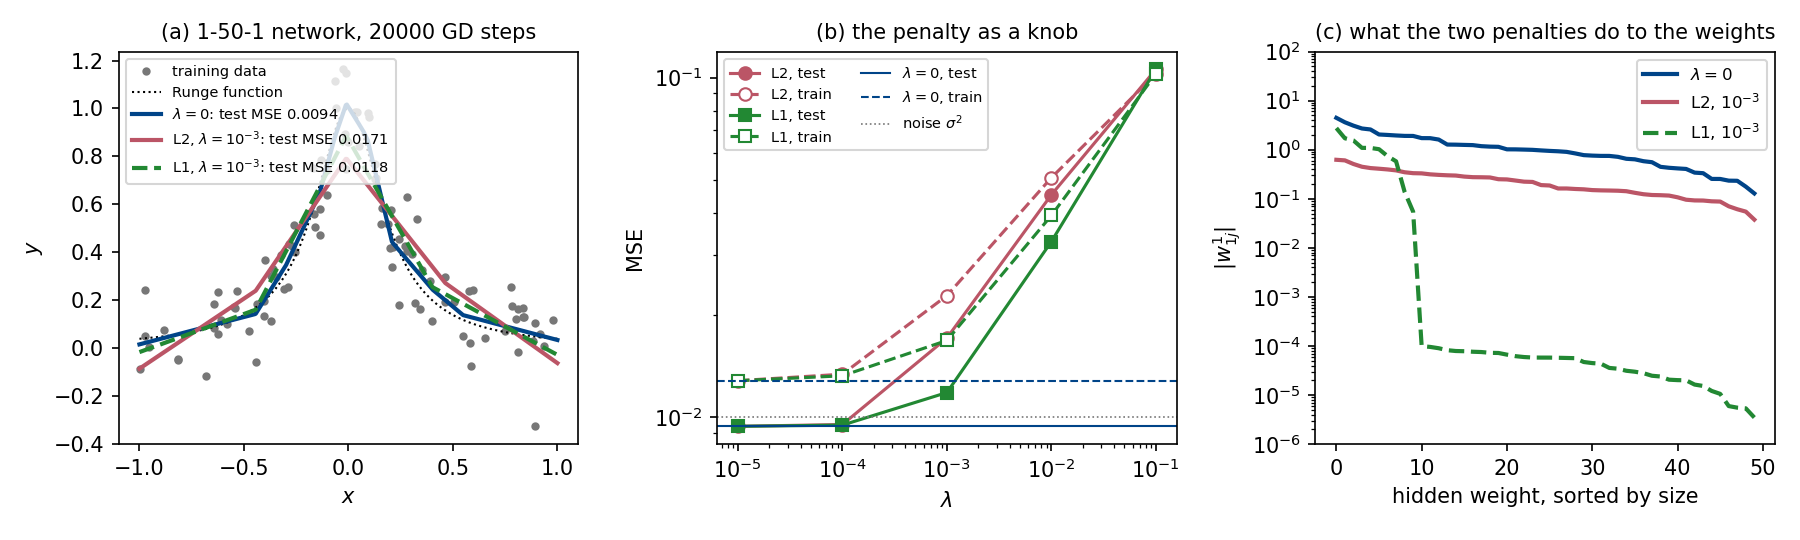

In [13]:
t0 = time.time()
res = fig_runge()
for key, val in res.items():
    if key == "n_small_weights":
        print("hidden weights below 1e-3 (of 50):", val)
    else:
        print(f"{key[0]:5s} lambda = {key[1]:<8g} train MSE {val[0]:.4f}  test MSE {val[1]:.4f}")
print(f"({time.time() - t0:.0f} s)")
Image("week41_runge.png", width=1000)

### Example 2, binary classification: the Wisconsin breast-cancer data

569 samples, 30 standardised features, target malignant/benign; sigmoid
output and cross entropy, $\ell_2$ with $\lambda = 10^{-4}$, minibatches of
32, $\gamma = 0.1$, 300 epochs, 455 training and 114 test samples. The
network with no hidden layer, `sizes = [30, 1]`, *is* logistic regression —
the same code with the loop over layers running once. One hidden layer of 16
sigmoid units has sixteen times the parameters, a lower training cost, and one
more test error out of 114: the classes are nearly linearly separable in these
features, there is no representation to learn, and one sample is well inside
the variance of a 114-sample test set. Measure with cross-validation before
believing either number.

In [14]:
def cancer_example(gamma=0.1, epochs=300, batch_size=32, hidden=16, lmbd2=1e-4):
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    data = load_breast_cancer()
    X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=2026)
    scaler = StandardScaler().fit(X_train)
    X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    out = {}
    for name, sizes in (("logistic regression (no hidden layer)", [30, 1]),
                        (f"one hidden layer of {hidden}", [30, hidden, 1])):
        layers = create_layers(sizes, "sigmoid", np.random.default_rng(2026))
        layers, hist = train(X_train, y_train[:, None], layers, "sigmoid", "binary", gamma=gamma, epochs=epochs,
                             batch_size=batch_size, lmbd2=lmbd2, X_test=X_test, y_test=y_test)
        out[name] = {"train": accuracy(X_train, y_train, layers, "sigmoid", "binary"),
                     "test": hist["test_accuracy"][-1], "cost": hist["cost"][-1],
                     "n_params": sum(W.size + b.size for W, b in layers)}
    return out, (X_train, X_test, y_train, y_test)


In [15]:
outc, _ = cancer_example()
for name, v in outc.items():
    print(f"{name:40s}: {v['n_params']:4d} parameters, train accuracy {v['train']:.4f}  "
          f"test accuracy {v['test']:.4f}  final cost {v['cost']:.4f}")

logistic regression (no hidden layer)   :   31 parameters, train accuracy 0.9868  test accuracy 0.9825  final cost 0.0522
one hidden layer of 16                  :  513 parameters, train accuracy 0.9912  test accuracy 0.9737  final cost 0.0500


### Example 3: MNIST, the full set

60 000 training and 10 000 test images of $28\times 28$ pixels, labels 0–9.
Each image is flattened to a row of 784 features in $[0, 1]$ and the labels
become one-hot rows. The loader looks for the repository's `mnist.npz` (in
`BookPrograms/chapter10_convolutional_networks/`) and otherwise downloads the
set once with `fetch_openml("mnist_784")`.

The network is `sizes = [784, 100, 10]` — 79 510 parameters — with a sigmoid
or a ReLU hidden layer, softmax output and the multiclass cross entropy, plain
gradient descent on minibatches of 100 (600 updates per epoch), $\gamma = 0.5$
for the sigmoid and $0.1$ for ReLU, 20 epochs. One epoch is some 30 Gflop,
one to two seconds of `numpy`.

In [16]:
def load_mnist():
    """The 70 000 MNIST images as (X_train, y_train, X_test, y_test), pixels scaled to [0, 1], 784 columns.

    Looks for the repository's mnist.npz first (no download needed) and falls
    back on scikit-learn's fetch_openml, which downloads 70 000 images once.
    """
    here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
    candidates = [os.path.join(here, "mnist.npz"),
                  os.path.join(here, "..", "BookPrograms", "chapter10_convolutional_networks", "mnist.npz"),
                  os.path.join(here, "..", "..", "BookML", "BookPrograms", "chapter10_convolutional_networks", "mnist.npz")]
    for path in candidates:
        if os.path.exists(path):
            d = np.load(path)
            X_train = d["x_train"].reshape(len(d["x_train"]), -1).astype(float) / 255.0
            X_test = d["x_test"].reshape(len(d["x_test"]), -1).astype(float) / 255.0
            return X_train, d["y_train"].astype(int), X_test, d["y_test"].astype(int)
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist.data.astype(float) / 255.0
    y = mnist.target.astype(int)
    return X[:60000], y[:60000], X[60000:], y[60000:]


def mnist_example(epochs=20, batch_size=100, hidden=100, lmbd2=0.0, gammas=None, verbose=False):
    """A 784-hidden-10 network with sigmoid and with ReLU hidden units on the full MNIST set."""
    gammas = {"sigmoid": 0.5, "relu": 0.1} if gammas is None else gammas
    X_train, y_train, X_test, y_test = load_mnist()
    Y_train = one_hot(y_train, 10)
    out = {}
    for act in ("sigmoid", "relu"):
        t0 = time.time()
        layers = create_layers([784, hidden, 10], act, np.random.default_rng(2026))
        layers, hist = train(X_train, Y_train, layers, act, "softmax", gamma=gammas[act], epochs=epochs,
                             batch_size=batch_size, lmbd2=lmbd2, X_test=X_test, y_test=y_test, verbose=verbose)
        out[act] = {"layers": layers, "history": hist, "time": time.time() - t0,
                    "train_accuracy": accuracy(X_train, y_train, layers, act, "softmax"),
                    "test_accuracy": hist["test_accuracy"][-1], "gamma": gammas[act]}
    return out, (X_train, y_train, X_test, y_test)


In [17]:
outm, datam = mnist_example(verbose=True)
for act, v in outm.items():
    print(f"{act:8s} gamma {v['gamma']}: train accuracy {v['train_accuracy']:.4f}  "
          f"test accuracy {v['test_accuracy']:.4f}  ({v['time']:.0f} s for 20 epochs)")

epoch   1: cost 0.2943  test accuracy 0.9183
epoch   2: cost 0.2377  test accuracy 0.9305
epoch   3: cost 0.1948  test accuracy 0.9419
epoch   4: cost 0.1631  test accuracy 0.9504
epoch   5: cost 0.1458  test accuracy 0.9543
epoch   6: cost 0.1282  test accuracy 0.9586
epoch   7: cost 0.1191  test accuracy 0.9609
epoch   8: cost 0.1066  test accuracy 0.9636
epoch   9: cost 0.0926  test accuracy 0.9672
epoch  10: cost 0.0876  test accuracy 0.9676
epoch  11: cost 0.0813  test accuracy 0.9692
epoch  12: cost 0.0730  test accuracy 0.9708
epoch  13: cost 0.0680  test accuracy 0.9719
epoch  14: cost 0.0639  test accuracy 0.9722
epoch  15: cost 0.0610  test accuracy 0.9740
epoch  16: cost 0.0561  test accuracy 0.9739
epoch  17: cost 0.0528  test accuracy 0.9745
epoch  18: cost 0.0504  test accuracy 0.9747
epoch  19: cost 0.0489  test accuracy 0.9750
epoch  20: cost 0.0475  test accuracy 0.9751
epoch   1: cost 0.2677  test accuracy 0.9266
epoch   2: cost 0.2036  test accuracy 0.9413
epoch   3:

epoch   2: cost 0.2377  test accuracy 0.9305


epoch   3: cost 0.1948  test accuracy 0.9419


epoch   4: cost 0.1631  test accuracy 0.9504


epoch   5: cost 0.1458  test accuracy 0.9543


...

epoch  16: cost 0.0474  test accuracy 0.9740


epoch  17: cost 0.0461  test accuracy 0.9747


epoch  18: cost 0.0426  test accuracy 0.9764


epoch  19: cost 0.0447  test accuracy 0.9747


epoch  20: cost 0.0395  test accuracy 0.9763
sigmoid  gamma 0.5: train accuracy 0.9874  test accuracy 0.9751  (16 s for 20 epochs)
relu     gamma 0.1: train accuracy 0.9897  test accuracy 0.9763  (10 s for 20 epochs)


Test accuracy $91.8\%/92.7\%$ after one epoch — already the level of
multinomial logistic regression on the raw pixels — $96.8\%/97.1\%$ after ten,
$97.51\%$ (sigmoid) and $97.63\%$ (ReLU) after twenty, on images the network
has never seen; training accuracy $98.74\%$ and $98.97\%$. ReLU is ahead by a
few tenths of a percent at every epoch with a five times smaller $\gamma$.

In [18]:
def fig_mnist(out, data, fname="week41_mnist.pdf"):
    X_train, y_train, X_test, y_test = data
    fig = plt.figure(figsize=(12, 3.8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 1, 1], wspace=0.3)
    gs_img = gs[0].subgridspec(2, 5, wspace=0.05, hspace=0.35)
    for k in range(10):
        ax = fig.add_subplot(gs_img[k // 5, k % 5])
        ax.imshow(X_train[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"label {y_train[k]}", fontsize=8, pad=2)
        ax.axis("off")
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])
    ep = np.arange(1, len(out["sigmoid"]["history"]["cost"]) + 1)
    for act, col in (("sigmoid", BLUE), ("relu", RED)):
        h = out[act]["history"]
        ax1.semilogy(ep, h["cost"], "o-", color=col, ms=3, label=rf"{act}, $\gamma={out[act]['gamma']}$")
        ax2.plot(ep, 100 * np.array(h["test_accuracy"]), "o-", color=col, ms=3,
                 label=f"{act}: {100 * h['test_accuracy'][-1]:.2f}%")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("training cross entropy")
    ax1.legend(fontsize=8)
    ax1.set_title("(b) cost on the 60 000 training images", fontsize=10)
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("test accuracy (%)")
    ax2.set_ylim(90, 100)
    ax2.legend(fontsize=8, loc="lower right")
    ax2.set_title("(c) accuracy on the 10 000 test images", fontsize=10)
    fig.text(0.05, 0.93, "(a) ten of the 60 000 training images", fontsize=10, ha="left")
    fig.subplots_adjust(left=0.03, right=0.99, top=0.88, bottom=0.15)
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)


def fig_mnist_errors(out, data, act="relu", fname="week41_mnist_errors.pdf", n_show=10):
    X_train, y_train, X_test, y_test = data
    layers = out[act]["layers"]
    P = predict(X_test, layers, act, "softmax")
    pred = np.argmax(P, axis=1)
    wrong = np.where(pred != y_test)[0]
    fig, axes = plt.subplots(2, n_show // 2, figsize=(12, 4.4))
    for ax, k in zip(axes.ravel(), wrong[:n_show]):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"true {y_test[k]}, predicted {pred[k]} ({100 * P[k, pred[k]]:.0f}%)", fontsize=8, pad=2)
        ax.axis("off")
    fig.suptitle(f"{act}: {len(wrong)} of the 10 000 test images are misclassified; the first {n_show}", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)
    conf = np.zeros((10, 10), dtype=int)
    for t, p in zip(y_test, pred):
        conf[t, p] += 1
    return len(wrong), conf


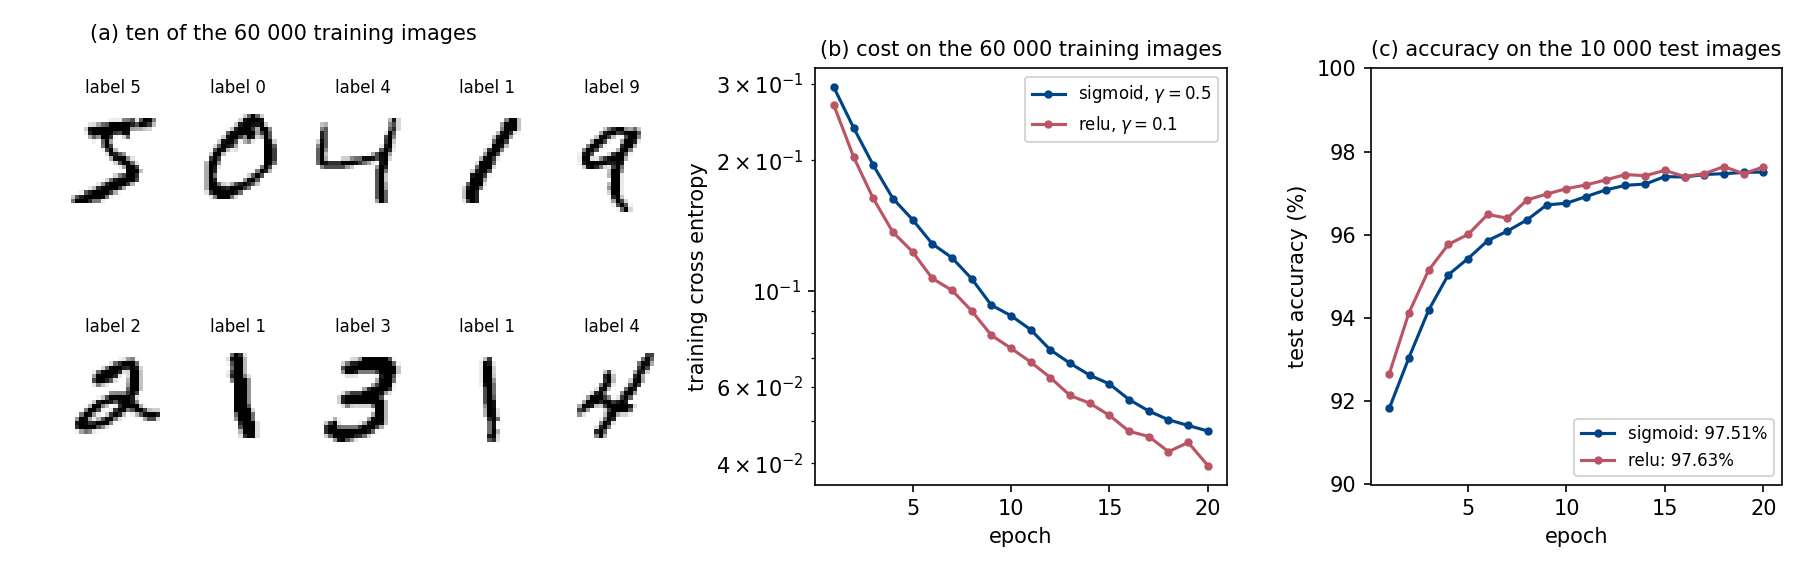

In [19]:
fig_mnist(outm, datam)
Image("week41_mnist.png", width=1000)

ReLU network: 237 of the 10 000 test images are misclassified
confusion matrix (rows true, columns predicted):
[[ 967    0    0    1    0    4    2    1    3    2]
 [   0 1123    4    0    0    1    2    1    4    0]
 [   4    1 1008    3    2    0    2    7    5    0]
 [   0    0    8  984    0    5    0    3    5    5]
 [   1    0    2    1  947    1    5    3    3   19]
 [   3    1    0    6    1  870    4    1    2    4]
 [   5    3    2    0    2    6  938    0    2    0]
 [   1    4   10    3    0    0    0 1000    2    8]
 [   3    0    4    7    4    4    3    3  943    3]
 [   3    2    1    6    5    1    0    5    3  983]]
largest off-diagonal entries: [(np.int64(19), 4, 9), (np.int64(10), 7, 2), (np.int64(8), 7, 9), (np.int64(8), 3, 2), (np.int64(7), 8, 3), (np.int64(7), 2, 7)]


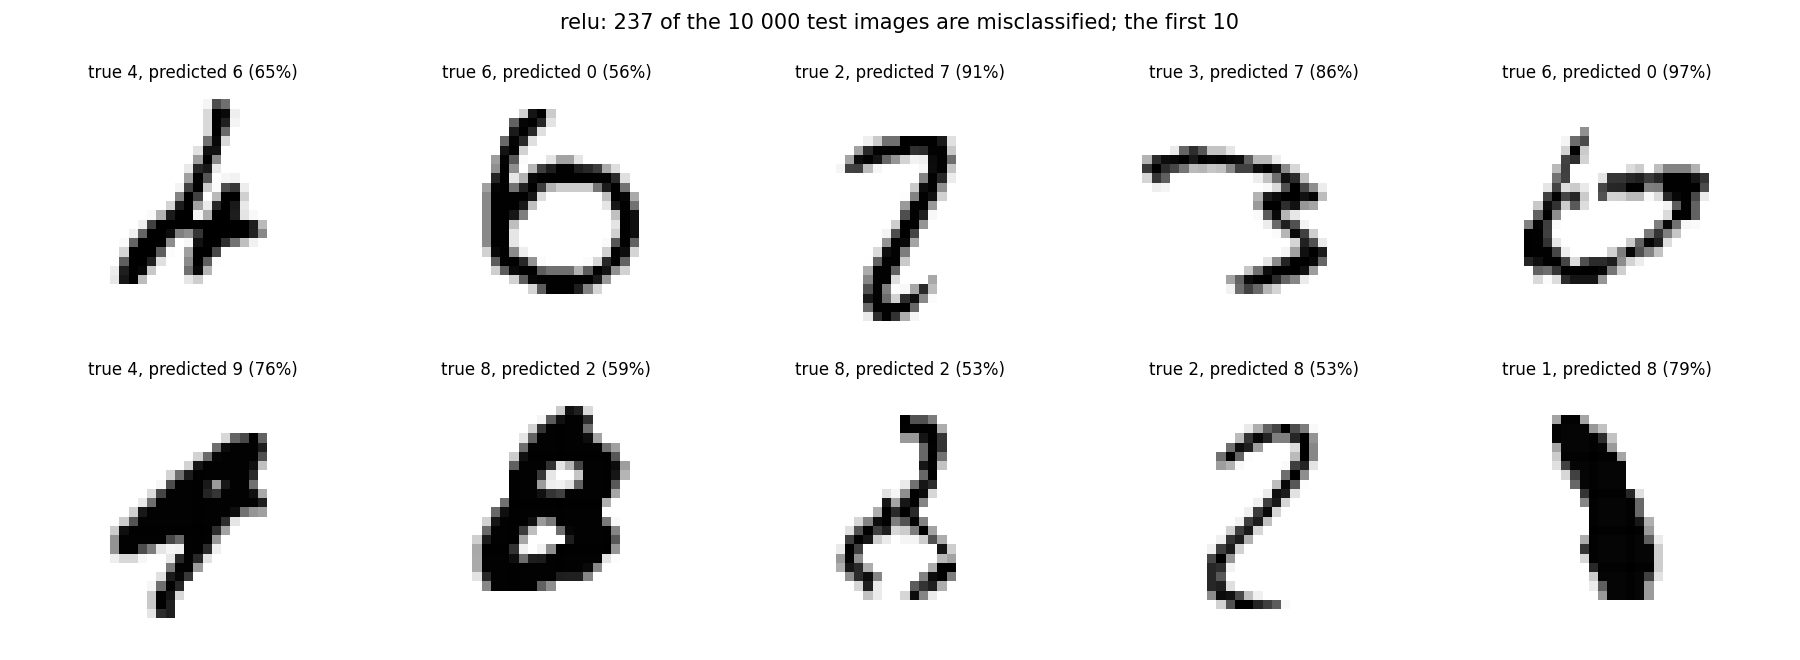

In [20]:
n_wrong, conf = fig_mnist_errors(outm, datam)
print(f"ReLU network: {n_wrong} of the 10 000 test images are misclassified")
print("confusion matrix (rows true, columns predicted):")
print(conf)
off = [(conf[i, j], i, j) for i in range(10) for j in range(10) if i != j]
print("largest off-diagonal entries:", sorted(off, reverse=True)[:6])
Image("week41_mnist_errors.png", width=900)

The errors are the pairs a person hesitates on — $4\to9$, $7\to2$, $3\to2$,
$7\to9$ — and the softmax probabilities of the wrong answers show the network
hesitating too. A softmax output is a *distribution* over the classes, not a
label: a $53\%$ "2" with "8" in second place is a different mistake from a
$97\%$ "0".

**Pause and think 5: is 97.6% good, and what would you change first?** More
epochs, since nothing has converged — but with a validation set split off the
training data to decide when to stop, because the test set must not choose
hyperparameters. Adam or momentum buy the same accuracy in fewer epochs, not a
higher ceiling; more units or a second layer raise the ceiling of this family
(800 units reach 98.4%) at the price of more variance. The errors themselves
point elsewhere: $4\to9$ and $7\to2$ are *shape* confusions, and a network
that treats every pixel as an independent feature cannot know that a stroke
moved one pixel to the right is the same stroke. That knowledge is what
convolutions add (Chapter 10), which is why they reach 99.7%.

## Tuesday and the exercises

Tuesday has one case: the feed-forward part of a network built step by step
on the digits data (`week41tuesday.ipynb`) — the structure of
`exercisesweek41.ipynb`, which does the same on the iris data with `jax.grad`
as the optional last step. Deadline **Friday October 9 at midnight**. Project
2, which builds on exactly the code of this notebook, is published after the
Project 1 deadline.